In [ ]:
import os
import math
import random
import numpy as np
from PIL import Image, ImageOps
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from torch.amp import autocast, GradScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count()
print(f"Detected GPUs: {N_GPUS}")

SEED = 42

IMG_SIZE    = 512
BATCH_SIZE  = 8
NUM_EPOCHS  = 30
LR          = 1e-4
WEIGHT_DECAY = 1e-4
FOCAL_GAMMA  = 2.5
NUM_WORKERS = 4
FREEZE_EPOCHS = 3

DATA_DIR       = "/kaggle/input/rsna-pneumonia-processed-dataset"
TRAIN_IMG_DIR  = os.path.join(DATA_DIR, "Training", "Images")
TRAIN_MASK_DIR = os.path.join(DATA_DIR, "Training", "Masks")
TEST_IMG_DIR   = os.path.join(DATA_DIR, "Test")

os.makedirs("checkpoints", exist_ok=True)

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()
print("start")


Detected GPUs: 2
start


In [ ]:
def gaussian2D(shape, sigma=1):
    m, n = [(ss - 1.) / 2. for ss in shape]
    y, x = np.ogrid[-m:m+1, -n:n+1]
    h = np.exp(-(x * x + y * y) / (2 * sigma * sigma))
    h[h < np.finfo(h.dtype).eps * h.max()] = 0
    return h

def draw_gaussian(heatmap, center, radius, k=1):
    diameter = 2 * radius + 1
    gaussian = gaussian2D((diameter, diameter), sigma=diameter / 6)

    x, y = int(center[0]), int(center[1])
    height, width = heatmap.shape[0:2]

    left, right = min(x, radius), min(width - x, radius + 1)
    top, bottom = min(y, radius), min(height - y, radius + 1)

    masked_heatmap = heatmap[y - top:y + bottom, x - left:x + right]
    masked_gaussian = gaussian[radius - top:radius + bottom, radius - left:radius + right]

    if min(masked_gaussian.shape) > 0 and min(masked_heatmap.shape) > 0:
        np.maximum(masked_heatmap, masked_gaussian * k, out=masked_heatmap)

    return heatmap

def gaussian_radius(det_size, min_overlap=0.7):
    height, width = det_size

    diagonal = np.sqrt(height**2 + width**2)
    radius = diagonal / 6.0

    radius = max(radius, 2.0)

    return radius



In [ ]:
class RSNAMultiLevelDataset(Dataset):
    def __init__(self, img_ids, img_dir, mask_dir,
                 img_size=IMG_SIZE,
                 strides=(8, 16, 32),
                 size_ranges=((0, 64), (64, 128), (128, 1e8)),
                 train=True):
        self.img_ids = img_ids
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.strides = strides
        self.size_ranges = size_ranges
        self.train = train

    def __len__(self):
        return len(self.img_ids)

    def _load_img_mask(self, img_id):
        img_path = os.path.join(self.img_dir, img_id)
        mask_path = os.path.join(self.mask_dir, img_id)

        img = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        img = img.resize((self.img_size, self.img_size))
        mask = mask.resize((self.img_size, self.img_size), resample=Image.NEAREST)

        if self.train and random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
            mask = mask.transpose(Image.FLIP_LEFT_RIGHT)

        return img, mask

    def _img_to_tensor(self, img):

        arr = np.array(img, dtype=np.float32) / 255.0

        enh_img = ImageOps.equalize(img)
        enh = np.array(enh_img, dtype=np.float32) / 255.0

        arr3 = np.stack([arr, arr, arr], axis=2)   # (H,W,3)
        enh3 = np.stack([enh, enh, enh], axis=2)   # (H,W,3)
        full = np.concatenate([arr3, enh3], axis=2)  # (H,W,6)

        t = torch.from_numpy(full).permute(2, 0, 1)  # (6,H,W)

        mean = torch.tensor(
            [0.485, 0.456, 0.406, 0.485, 0.456, 0.406],
            dtype=torch.float32
        ).view(6, 1, 1)
        std = torch.tensor(
            [0.229, 0.224, 0.225, 0.229, 0.224, 0.225],
            dtype=torch.float32
        ).view(6, 1, 1)

        t = (t - mean) / std
        return t

    def _mask_to_box(self, mask):
        m = np.array(mask, dtype=np.uint8)
        pos = np.where(m > 0)
        if len(pos[0]) == 0:
            return None
        y_min = int(pos[0].min())
        y_max = int(pos[0].max())
        x_min = int(pos[1].min())
        x_max = int(pos[1].max())
        return [x_min, y_min, x_max, y_max]

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img, mask = self._load_img_mask(img_id)
        img_t = self._img_to_tensor(img)

        box = self._mask_to_box(mask)

        heatmaps = []
        reg_maps = []
        reg_masks = []

        for stride in self.strides:
            H = self.img_size // stride
            W = self.img_size // stride
            heatmaps.append(torch.zeros((1, H, W), dtype=torch.float32))
            reg_maps.append(torch.zeros((4, H, W), dtype=torch.float32))
            reg_masks.append(torch.zeros((1, H, W), dtype=torch.float32))

        if box is not None:
            x1, y1, x2, y2 = box
            cx = (x1 + x2) / 2.0
            cy = (y1 + y2) / 2.0
            w = x2 - x1
            h = y2 - y1
            l = cx - x1
            t = cy - y1
            r = x2 - cx
            b = y2 - cy
            max_dist = max(l, t, r, b)

            level_idx = len(self.strides) - 1
            for i, (low, high) in enumerate(self.size_ranges):
                if low <= max_dist < high:
                    level_idx = i
                    break

            stride = self.strides[level_idx]
            H = self.img_size // stride
            W = self.img_size // stride

            gx = cx / stride
            gy = cy / stride
            gi = int(gx)
            gj = int(gy)

            if 0 <= gi < W and 0 <= gj < H:
                radius = gaussian_radius((h / stride, w / stride))
                radius = max(0, int(radius))

                heatmap_np = heatmaps[level_idx][0].numpy()
                draw_gaussian(heatmap_np, (gi, gj), radius)
                heatmaps[level_idx][0] = torch.from_numpy(heatmap_np)

                reg_maps[level_idx][:, gj, gi] = torch.tensor(
                    [l / stride, t / stride, r / stride, b / stride],
                    dtype=torch.float32
                )
                reg_masks[level_idx][0, gj, gi] = 1.0

            has_box = 1.0
        else:
            x1 = y1 = x2 = y2 = 0.0
            has_box = 0.0

        gt_box = torch.tensor([x1, y1, x2, y2, has_box], dtype=torch.float32)

        return img_t, heatmaps, reg_maps, reg_masks, gt_box, img_id


In [ ]:
def multilevel_collate(batch):
    imgs = torch.stack([b[0] for b in batch], dim=0)
    gt_boxes = torch.stack([b[4] for b in batch], dim=0)
    img_ids = [b[5] for b in batch]

    num_levels = len(batch[0][1])

    heatmaps_batch = []
    reg_maps_batch = []
    reg_masks_batch = []

    for lvl in range(num_levels):
        heatmaps_batch.append(torch.stack([b[1][lvl] for b in batch], dim=0))
        reg_maps_batch.append(torch.stack([b[2][lvl] for b in batch], dim=0))
        reg_masks_batch.append(torch.stack([b[3][lvl] for b in batch], dim=0))

    return imgs, heatmaps_batch, reg_maps_batch, reg_masks_batch, gt_boxes, img_ids



In [ ]:
class FPNBackbone(nn.Module):
    def __init__(self, pretrained=True, out_channels=256):
        super().__init__()
        resnet = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
        )
        old_conv = resnet.conv1
        new_conv = nn.Conv2d(
            6, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None
        )
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight
            new_conv.weight[:, 3:] = old_conv.weight
        resnet.conv1 = new_conv

        self.stem = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool
        )
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.lateral3 = nn.Conv2d(512, out_channels, 1)
        self.lateral4 = nn.Conv2d(1024, out_channels, 1)
        self.lateral5 = nn.Conv2d(2048, out_channels, 1)

        self.smooth3 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.smooth4 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.smooth5 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
    def forward(self, x):
        x = self.stem(x)
        c2 = self.layer1(x)
        c3 = self.layer2(c2)
        c4 = self.layer3(c3)
        c5 = self.layer4(c4)

        p5 = self.lateral5(c5)
        p4 = self.lateral4(c4) + F.interpolate(p5, scale_factor=2, mode="nearest")
        p3 = self.lateral3(c3) + F.interpolate(p4, scale_factor=2, mode="nearest")

        p3 = self.smooth3(p3)
        p4 = self.smooth4(p4)
        p5 = self.smooth5(p5)

        return [p3, p4, p5]


In [ ]:
class DetectionHead(nn.Module):
    def __init__(self, in_channels=256, num_classes=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, in_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.cls_head = nn.Conv2d(in_channels, num_classes, 3, padding=1)
        self.reg_head = nn.Conv2d(in_channels, 4, 3, padding=1)

        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)
        nn.init.constant_(self.cls_head.bias, bias_value)

    def forward_single(self, x):
        x = self.conv(x)
        cls_logits = self.cls_head(x)
        reg = F.relu(self.reg_head(x))
        return cls_logits, reg

    def forward(self, feats):
        cls_outputs = []
        reg_outputs = []
        for f in feats:
            cls, reg = self.forward_single(f)
            cls_outputs.append(cls)
            reg_outputs.append(reg)
        return cls_outputs, reg_outputs


In [ ]:
class AnchorFreeDetectorMS(nn.Module):
    def __init__(self, num_levels=3):
        super().__init__()
        self.backbone = FPNBackbone(pretrained=True)
        self.head = DetectionHead()
        self.num_levels = num_levels

    def forward(self, x):
        feats = self.backbone(x)
        cls_list, reg_list = self.head(feats[:self.num_levels])
        return cls_list, reg_list



In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        logits = torch.clamp(logits, min=-10, max=10)
        prob = torch.sigmoid(logits)

        prob = torch.clamp(prob, min=1e-7, max=1-1e-7)

        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")

        p_t = prob * targets + (1 - prob) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        loss = alpha_t * (1 - p_t) ** self.gamma * ce_loss

        if self.reduction == "mean":
            num_pos = targets.sum().clamp(min=1.0)
            return loss.sum() / num_pos
        elif self.reduction == "sum":
            return loss.sum()
        return loss



In [ ]:
def regression_loss(pred, target, mask):
    mask = mask.expand_as(pred)
    diff = F.smooth_l1_loss(pred * mask, target * mask, reduction="sum")
    num_pos = mask.sum().clamp(min=1.0)
    return diff / num_pos


def freeze_backbone(model):
    base = get_base_model(model)
    for p in base.backbone.parameters():
        p.requires_grad = False
    print("Backbone frozen")


def unfreeze_backbone(model):
    base = get_base_model(model)
    for p in base.backbone.parameters():
        p.requires_grad = True
    print("Backbone unfrozen")
def train_one_epoch(epoch, model, train_loader, optimizer, focal_loss, device, scaler):
    model.train()
    running_loss = 0.0
    running_cls_loss = 0.0
    running_reg_loss = 0.0

    # freeze / unfreeze backbone
    if epoch == 1:
        freeze_backbone(model)
    if epoch == FREEZE_EPOCHS:
        unfreeze_backbone(model)

    for imgs, heatmaps, reg_maps, reg_masks, gt_boxes, img_ids in tqdm(train_loader, desc=f"Train {epoch}"):
        imgs      = imgs.to(device)
        heatmaps  = [h.to(device) for h in heatmaps]
        reg_maps  = [r.to(device) for r in reg_maps]
        reg_masks = [m.to(device) for m in reg_masks]

        optimizer.zero_grad()

        with autocast(device_type="cuda"):

            cls_outputs, reg_outputs = model(imgs)

            loss_cls_total = 0.0
            loss_reg_total = 0.0
            for lvl in range(len(cls_outputs)):
                cls_pred = cls_outputs[lvl]
                reg_pred = reg_outputs[lvl]
                cls_gt   = heatmaps[lvl]
                reg_gt   = reg_maps[lvl]
                reg_m    = reg_masks[lvl]

                loss_cls = focal_loss(cls_pred, cls_gt)
                loss_reg = regression_loss(reg_pred, reg_gt, reg_m)

                loss_cls_total += loss_cls
                loss_reg_total += loss_reg

            loss_cls_avg = loss_cls_total / len(cls_outputs)
            loss_reg_avg = loss_reg_total / len(cls_outputs)
            loss = loss_cls_avg + loss_reg_avg

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss     += loss.item() * imgs.size(0)
        running_cls_loss += loss_cls_avg.item() * imgs.size(0)
        running_reg_loss += loss_reg_avg.item() * imgs.size(0)

    avg_loss = running_loss / len(train_loader.dataset)
    avg_cls  = running_cls_loss / len(train_loader.dataset)
    avg_reg  = running_reg_loss / len(train_loader.dataset)

    print(f"  [Train] Total: {avg_loss:.4f} | Cls: {avg_cls:.4f} | Reg: {avg_reg:.4f}")
    return avg_loss
def get_base_model(model: nn.Module):
    return model.module if isinstance(model, nn.DataParallel) else model


def get_model_state(model: nn.Module):
    return get_base_model(model).state_dict()


def load_model_state(model: nn.Module, state_dict):
    base = get_base_model(model)
    base.load_state_dict(state_dict)

In [ ]:
def box_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])
    union = area1 + area2 - inter + 1e-6
    return inter / union


def compute_map_from_detections(preds, gts, iou_thresh=0.5):
    if len(gts) == 0:
        return 0.0

    total_gts = sum(len(boxes) for boxes in gts.values())
    if total_gts == 0:
        return 0.0

    preds_sorted = sorted(preds, key=lambda x: x["score"], reverse=True)

    gt_used = {
        img_id: np.zeros(len(boxes), dtype=bool)
        for img_id, boxes in gts.items()
    }

    tp = []
    fp = []

    for pred in preds_sorted:
        img_id = pred["image_id"]
        pbox = pred["box"]

        if img_id not in gts or len(gts[img_id]) == 0:
            tp.append(0)
            fp.append(1)
            continue

        gt_boxes = gts[img_id]
        ious = [box_iou(pbox, gt_box) for gt_box in gt_boxes]
        best_iou = max(ious)
        best_idx = int(np.argmax(ious))

        if best_iou >= iou_thresh and not gt_used[img_id][best_idx]:
            tp.append(1)
            fp.append(0)
            gt_used[img_id][best_idx] = True
        else:
            tp.append(0)
            fp.append(1)

    tp = np.array(tp, dtype=np.float32)
    fp = np.array(fp, dtype=np.float32)
    if len(tp) == 0:
        return 0.0

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    recall = tp_cum / total_gts
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1e-6)

    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))

    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

    return float(ap)
def decode_multilevel(cls_list, reg_list, strides, score_thresh=0.05, topk_per_level=1):
    B = cls_list[0].shape[0]
    all_preds = [[] for _ in range(B)]

    for lvl, (cls_logits, reg, stride) in enumerate(zip(cls_list, reg_list, strides)):
        B, _, H, W = cls_logits.shape
        prob = torch.sigmoid(cls_logits)

        for b in range(B):
            scores = prob[b, 0].flatten()
            topk_scores, topk_idx = scores.topk(topk_per_level)
            for s, idx in zip(topk_scores, topk_idx):
                s_val = s.item()
                if s_val < score_thresh:
                    continue
                y = (idx // W).item()
                x = (idx % W).item()
                l, t, r, bdist = reg[b, :, y, x]

                cx = (x + 0.5) * stride
                cy = (y + 0.5) * stride
                x1 = cx - l * stride
                y1 = cy - t * stride
                x2 = cx + r * stride
                y2 = cy + bdist * stride
                all_preds[b].append([x1.item(), y1.item(), x2.item(), y2.item(), s_val])

    final_preds = []
    for b in range(B):
        if len(all_preds[b]) == 0:
            final_preds.append([])
        else:
            all_preds[b].sort(key=lambda x: x[4], reverse=True)
            final_preds.append(all_preds[b][:1])
    return final_preds


def validate(epoch, model, val_loader, device, iou_thresh=0.5, score_thresh=0.1):
    model.eval()
    running_loss = 0.0
    ious = []

    all_preds = []
    all_gts = {}

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Val {epoch}"):
            imgs, heatmaps, reg_maps, reg_masks, gt_boxes, img_ids = batch

            imgs = imgs.to(device)
            gt_boxes = gt_boxes.to(device)

            heatmaps  = [h.to(device) for h in heatmaps]
            reg_maps  = [r.to(device) for r in reg_maps]
            reg_masks = [m.to(device) for m in reg_masks]

            cls_outputs, reg_outputs = model(imgs)

            num_levels = len(cls_outputs)
            loss_cls = 0.0
            loss_reg = 0.0

            for lvl in range(num_levels):
                loss_cls = loss_cls + focal_loss(cls_outputs[lvl], heatmaps[lvl])
                loss_reg = loss_reg + regression_loss(
                    reg_outputs[lvl],
                    reg_maps[lvl],
                    reg_masks[lvl]
                )

            loss = (loss_cls + 2.0 * loss_reg) / num_levels
            running_loss += loss.item() * imgs.size(0)

            preds_batch = decode_multilevel(
                cls_outputs,
                reg_outputs,
                strides=[8, 16, 32],
                score_thresh=score_thresh,
                topk_per_level=50
            )

            batch_size = imgs.size(0)
            for b in range(batch_size):
                img_id = img_ids[b]
                if isinstance(img_id, bytes):
                    img_id = img_id.decode()

                has_box = gt_boxes[b, 4].item() > 0.5

                if has_box:
                    gt = gt_boxes[b, :4].cpu().tolist()
                    all_gts.setdefault(img_id, []).append(gt)

                if has_box and len(preds_batch[b]) > 0:
                    pred_main = preds_batch[b][0][:4]
                    ious.append(box_iou(pred_main, gt))

                for (x1, y1, x2, y2, score) in preds_batch[b]:
                    all_preds.append({
                        "image_id": img_id,
                        "score": float(score),
                        "box": [float(x1), float(y1), float(x2), float(y2)]
                    })

    mean_loss = running_loss / len(val_loader.dataset)
    mean_iou  = float(np.mean(ious)) if len(ious) > 0 else 0.0

    map50 = compute_map_from_detections(all_preds, all_gts, iou_thresh=iou_thresh)

    print(f"Val Epoch {epoch} | loss={mean_loss:.4f} | mean IoU={mean_iou:.4f} | mAP@0.5={map50:.4f}")
    return mean_loss, mean_iou, map50


In [ ]:
print("Setting up data loaders...")
all_imgs = sorted([f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith(".png")])

train_ids, val_ids = train_test_split(
    all_imgs,
    test_size=0.2,
    random_state=SEED
)

STRIDES = (8, 16, 32)

train_dataset = RSNAMultiLevelDataset(
    img_ids=train_ids,
    img_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    img_size=IMG_SIZE,
    strides=STRIDES,
    train=True
)

val_dataset = RSNAMultiLevelDataset(
    img_ids=val_ids,
    img_dir=TRAIN_IMG_DIR,
    mask_dir=TRAIN_MASK_DIR,
    img_size=IMG_SIZE,
    strides=STRIDES,
    train=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=multilevel_collate
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    collate_fn=multilevel_collate
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

print("Initializing model...")
base_model = AnchorFreeDetectorMS(num_levels=3)
if N_GPUS > 1:
    print(f"Using {N_GPUS} GPUs with DataParallel")
    model = nn.DataParallel(base_model).to(DEVICE)
else:
    model = base_model.to(DEVICE)
print(f"Params (M): {sum(p.numel() for p in model.parameters()) / 1e6:.3f}")

focal_loss = FocalLoss(gamma=FOCAL_GAMMA).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

focal_loss = FocalLoss(gamma=FOCAL_GAMMA).to(DEVICE)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

scaler = GradScaler(device="cuda")

print("\nTraining setup complete! Ready to train.")
print(f"Device: {DEVICE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LR}")
print(f"Number of epochs: {NUM_EPOCHS}")


Setting up data loaders...
Train: 21347, Val: 5337
Initializing model...
Using 2 GPUs with DataParallel
Params (M): 27.398

Training setup complete! Ready to train.
Device: cuda
Batch size: 8
Learning rate: 0.0001
Number of epochs: 20


In [ ]:


resume = True

if resume and os.path.exists("last_checkpoint.pth"):
    ckpt = torch.load("last_checkpoint.pth", map_location=DEVICE)
    load_model_state(model, ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    if "scheduler_state" in ckpt:
        scheduler.load_state_dict(ckpt["scheduler_state"])
    start_epoch = ckpt["epoch"] + 1
    best_iou = ckpt.get("best_iou", 0.0)
    best_map = ckpt.get("best_map", 0.0)
    print(f"Resuming from epoch {start_epoch}, best_iou={best_iou:.4f}, best_map={best_map:.4f}")
else:
    start_epoch = 1
    best_iou = 0.0
    best_map = 0.0
    print("Start training from scratch.")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    print(f"\n========== Epoch {epoch} ==========")

    train_loss = train_one_epoch(epoch, model, train_loader, optimizer, focal_loss, DEVICE, scaler)
    val_loss, val_iou, val_map = validate(epoch, model, val_loader, DEVICE)
    scheduler.step()

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} | "
          f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f} | mAP@0.5={val_map:.4f}")

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), "checkpoints/best_multiscale_iou.pth")
        print(f">> New BEST (IoU) model: {best_iou:.4f}")

    if val_map > best_map:
        best_map = val_map
        torch.save(model.state_dict(), "checkpoints/best_multiscale_map.pth")
        print(f">> New BEST (mAP) model, mAP@0.5 = {best_map:.4f}")

    torch.save({
     "epoch": epoch,
     "best_iou": best_iou,
     "best_map": best_map,
     "model_state": get_model_state(model),
     "optimizer_state": optimizer.state_dict(),
     "scheduler_state": scheduler.state_dict()
},   "last_checkpoint.pth")


print("\n" + "="*50)
print("Training Complete!")
print(f"Best IoU: {best_iou:.4f}")
print(f"Best mAP@0.5: {best_map:.4f}")
print("="*50)

Start training from scratch.

========== Epoch 1 ==========
Backbone frozen


Train 1:   0%|          | 0/2669 [00:00<?, ?it/s]

  [Train] Total: 0.4962 | Cls: 0.1511 | Reg: 0.3451


Val 1:   0%|          | 0/668 [00:00<?, ?it/s]

Val Epoch 1 | loss=0.7232 | mean IoU=0.4796 | mAP@0.5=0.1486
Epoch 1: train_loss=0.4962 | val_loss=0.7232 | val_iou=0.4796 | mAP@0.5=0.1486
>> New BEST (IoU) model: 0.4796
>> New BEST (mAP) model, mAP@0.5 = 0.1486

========== Epoch 2 ==========


...

Val Epoch 19 | loss=0.4398 | mean IoU=0.5168 | mAP@0.5=0.2999
Epoch 19: train_loss=0.1100 | val_loss=0.4398 | val_iou=0.5168 | mAP@0.5=0.2999

========== Epoch 20 ==========


Train 20:   0%|          | 0/2669 [00:00<?, ?it/s]

  [Train] Total: 0.1064 | Cls: 0.0930 | Reg: 0.0134


Val 20:   0%|          | 0/668 [00:00<?, ?it/s]

Val Epoch 20 | loss=0.4391 | mean IoU=0.5203 | mAP@0.5=0.2918
Epoch 20: train_loss=0.1064 | val_loss=0.4391 | val_iou=0.5203 | mAP@0.5=0.2918

Training Complete!
Best IoU: 0.5841
Best mAP@0.5: 0.3093


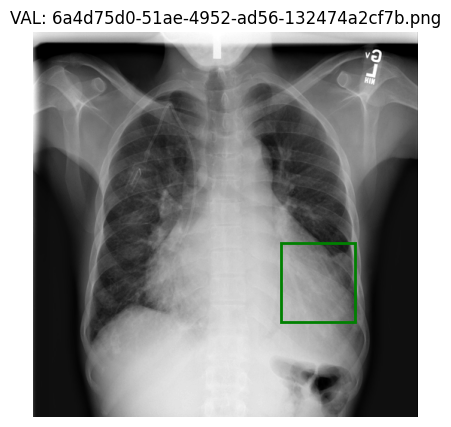

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_val_sample(idx=0, score_thresh=0.1):
    model.eval()

    img, heatmaps, reg_maps, reg_masks, gt_box, img_id = val_dataset[idx]

    with torch.no_grad():
        cls_outputs, reg_outputs = model(img.unsqueeze(0).to(DEVICE))

    preds = decode_multilevel(
        cls_outputs,
        reg_outputs,
        strides=[8, 16, 32],
        score_thresh=score_thresh,
        topk_per_level=10
    )

    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = img_np * 0.25 + 0.5
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(5,5))
    plt.imshow(img_np[..., 0], cmap="gray")

    ax = plt.gca()

    if gt_box[4] == 1:
        x1, y1, x2, y2 = gt_box[:4]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='g', facecolor='none', label='GT'
        )
        ax.add_patch(rect)

    if len(preds[0]) > 0:
        x1, y1, x2, y2, score = preds[0][0]
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='r', facecolor='none', label=f'Pred ({score:.2f})'
        )
        ax.add_patch(rect)

    plt.title(f"VAL: {img_id}")
    plt.axis('off')
    plt.show()

show_val_sample(idx=0, score_thresh=0.1)


In [ ]:
def get_base_model(model):
    return model.module if isinstance(model, nn.DataParallel) else model


In [ ]:

def calculate_iou_xywh(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    boxAArea = boxA[2] * boxA[3]
    boxBArea = boxB[2] * boxB[3]

    unionArea = boxAArea + boxBArea - interArea

    if unionArea == 0: return 0
    return interArea / unionArea

def get_score_at_threshold(gt_boxes, pred_boxes, threshold):

    if len(gt_boxes) == 0:
        return 1.0 if len(pred_boxes) == 0 else 0.0
    if len(pred_boxes) == 0:
        return 0.0

    pred_boxes = sorted(pred_boxes, key=lambda x: x[4], reverse=True)

    tp = 0
    fp = 0
    gt_matched = [False] * len(gt_boxes)

    for p_box in pred_boxes:
        best_iou = 0
        best_gt_idx = -1

        for i, g_box in enumerate(gt_boxes):
            if gt_matched[i]: continue

            iou = calculate_iou_xywh(p_box[:4], g_box)

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i

        if best_iou >= threshold:
            tp += 1
            gt_matched[best_gt_idx] = True
        else:
            fp += 1

    fn = len(gt_boxes) - sum(gt_matched)
    return tp / (tp + fp + fn)

def evaluate_rsna_official(ground_truth_dict, prediction_dict):

    image_ids = list(ground_truth_dict.keys())
    thresholds = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
    final_scores = []

    for img_id in image_ids:
        gts = ground_truth_dict.get(img_id, [])
        preds = prediction_dict.get(img_id, [])

        img_score = np.mean([get_score_at_threshold(gts, preds, t) for t in thresholds])
        final_scores.append(img_score)

    mean_score = np.mean(final_scores)

    print("\n" + "="*40)
    print(f" KẾT QUẢ CUỐI CÙNG: {mean_score:.5f}")
    print("="*40)
    return mean_score

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm

def get_base_model(model: nn.Module):
    return model.module if isinstance(model, nn.DataParallel) else model

ckpt_path = "checkpoints/best_multiscale_map.pth"
assert os.path.exists(ckpt_path), f"Not found: {ckpt_path}"

base_model = AnchorFreeDetectorMS(num_levels=3)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(base_model).to(DEVICE)
else:
    model = base_model.to(DEVICE)

state = torch.load(ckpt_path, map_location=DEVICE)

if isinstance(state, dict) and len(state) > 0:
    first_key = next(iter(state.keys()))
    if first_key.startswith("module."):
        from collections import OrderedDict
        state = OrderedDict((k.replace("module.", "", 1), v) for k, v in state.items())

get_base_model(model).load_state_dict(state, strict=True)
model.eval()

print("Loaded:", ckpt_path)


Loaded: checkpoints/best_multiscale_map.pth


In [ ]:
def xyxy_to_xywh(box_xyxy):
    x1, y1, x2, y2 = box_xyxy
    w = max(0.0, x2 - x1)
    h = max(0.0, y2 - y1)
    return [float(x1), float(y1), float(w), float(h)]


In [ ]:
from IPython.display import FileLink
FileLink("checkpoints/best_multiscale_iou.pth")
FileLink("checkpoints/best_multiscale_map.pth")

/kaggle/working/checkpoints/best_multiscale_iou.pth

In [ ]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, precision_recall_curve
from tqdm import tqdm


def calculate_iou_xywh(boxA, boxB):
    """
    boxA: [x,y,w,h]
    boxB: [x,y,w,h]
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    interW = max(0.0, xB - xA)
    interH = max(0.0, yB - yA)
    inter = interW * interH

    areaA = max(0.0, boxA[2]) * max(0.0, boxA[3])
    areaB = max(0.0, boxB[2]) * max(0.0, boxB[3])
    union = areaA + areaB - inter

    if union <= 0:
        return 0.0
    return float(inter / union)


def get_score_at_threshold(gt_boxes, pred_boxes, threshold):

    if len(gt_boxes) == 0:
        return 1.0 if len(pred_boxes) == 0 else 0.0

    if len(pred_boxes) == 0:
        return 0.0

    pred_boxes = sorted(pred_boxes, key=lambda x: x[4], reverse=True)

    tp, fp = 0, 0
    gt_matched = [False] * len(gt_boxes)

    for p in pred_boxes:
        best_iou = 0.0
        best_gt = -1

        for i, g in enumerate(gt_boxes):
            if gt_matched[i]:
                continue
            iou = calculate_iou_xywh(p[:4], g)
            if iou > best_iou:
                best_iou = iou
                best_gt = i

        if best_iou >= threshold and best_gt >= 0:
            tp += 1
            gt_matched[best_gt] = True
        else:
            fp += 1

    fn = len(gt_boxes) - sum(gt_matched)
    denom = tp + fp + fn
    return float(tp / denom) if denom > 0 else 0.0


def evaluate_rsna_official(ground_truth_dict, prediction_dict):

    image_ids = list(ground_truth_dict.keys())
    thresholds = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]
    final_scores = []

    for img_id in image_ids:
        gts = ground_truth_dict.get(img_id, [])
        preds = prediction_dict.get(img_id, [])
        img_score = np.mean([get_score_at_threshold(gts, preds, t) for t in thresholds])
        final_scores.append(img_score)

    mean_score = float(np.mean(final_scores)) if len(final_scores) > 0 else 0.0
    return mean_score



def xyxy_to_xywh(x1, y1, x2, y2):
    w = max(0.0, float(x2 - x1))
    h = max(0.0, float(y2 - y1))
    return [float(x1), float(y1), w, h]



def get_rsna_score(
    model,
    loader,
    device,
    decode_multilevel,
    strides=(8, 16, 32),
    score_thresh=0.1,
    topk_per_level=50,
    max_preds_per_image=50
):

    model.eval()

    y_true_cls = []
    y_pred_cls = []

    ground_truth_dict = {}
    prediction_dict = {}

    with torch.no_grad():
        for batch in tqdm(loader, desc="Inference"):
            imgs, heatmaps, reg_maps, reg_masks, gt_boxes, img_ids = batch

            imgs = imgs.to(device)
            gt_boxes = gt_boxes.to(device)

            cls_outputs, reg_outputs = model(imgs)

            preds_batch = decode_multilevel(
                cls_outputs,
                reg_outputs,
                strides=list(strides),
                score_thresh=score_thresh,
                topk_per_level=topk_per_level
            )

            B = imgs.size(0)
            for b in range(B):
                img_id = img_ids[b]
                if isinstance(img_id, bytes):
                    img_id = img_id.decode()

                has_box = (gt_boxes[b, 4].item() > 0.5)

                # ---------- GT dict ----------
                if has_box:
                    gx1, gy1, gx2, gy2 = gt_boxes[b, :4].detach().cpu().tolist()
                    ground_truth_dict.setdefault(img_id, []).append(xyxy_to_xywh(gx1, gy1, gx2, gy2))
                    y_true_cls.append(1)
                else:
                    ground_truth_dict.setdefault(img_id, [])
                    y_true_cls.append(0)

                # ---------- Pred dict ----------
                preds = preds_batch[b] if preds_batch is not None else []
                if preds is None:
                    preds = []

                preds = sorted(preds, key=lambda x: x[4], reverse=True)[:max_preds_per_image]

                cls_score = float(preds[0][4]) if len(preds) > 0 else 0.0
                y_pred_cls.append(cls_score)

                pred_xywh_score = []
                for (x1, y1, x2, y2, sc) in preds:
                    pred_xywh_score.append(xyxy_to_xywh(x1, y1, x2, y2) + [float(sc)])

                prediction_dict[img_id] = pred_xywh_score

    y_true_cls = np.asarray(y_true_cls, dtype=np.int32)
    y_pred_cls = np.asarray(y_pred_cls, dtype=np.float32)

    try:
        auc = float(roc_auc_score(y_true_cls, y_pred_cls))
        p, r, _ = precision_recall_curve(y_true_cls, y_pred_cls)
        f1 = 2 * (p * r) / (p + r + 1e-6)
        best_f1 = float(np.max(f1)) if len(f1) > 0 else 0.0
    except ValueError:
        auc, best_f1 = 0.0, 0.0

    rsna_mean = evaluate_rsna_official(ground_truth_dict, prediction_dict)

    print("\n" + "=" * 50)
    print("EVALUATION RESULTS (Updated RSNA Score)")
    print("=" * 50)
    print(f"🔹 Classification AUC:         {auc:.4f}")
    print(f"🔹 Classification Best F1:     {best_f1:.4f}")
    print(f"🔸 RSNA mean score (0.4-0.75): {rsna_mean:.4f}")
    print("=" * 50)

    return auc, best_f1, rsna_mean


In [ ]:
auc, best_f1, rsna_mean = get_rsna_score(
    model=model,
    loader=val_loader,
    device=DEVICE,
    decode_multilevel=decode_multilevel,
    strides=(8,16,32),
    score_thresh=0.1,
    topk_per_level=50,
    max_preds_per_image=50
)


Inference: 100%|██████████| 668/668 [02:18<00:00,  4.82it/s]



EVALUATION RESULTS (Updated RSNA Score)
🔹 Classification AUC:         0.8330
🔹 Classification Best F1:     0.6321
🔸 RSNA mean score (0.4-0.75): 0.6615
